# 08_优化算法-超参数优化

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇数据：`dataset/titanic.csv`。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。
- 删除在切分前重复抽样到 10 万行的步骤，避免同一个乘客同时进入训练集和测试集；森林无需标准化。
- 更新 max_features 的合法候选，并使用 12 次贝叶斯搜索与 50–200 棵树作为教学规模。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


今儿咱们聊聊**超参数优化**的内容\~

超参数优化（Hyperparameter Optimization）是指在机器学习模型中，寻找最优的超参数组合，以提升模型性能的过程。

超参数是模型在训练之前必须设置的参数，它们并不能通过训练数据自动学习到，而是由人们事先设定的。例如，神经网络中的学习率、层数、每层的神经元数量，或者决策树中的最大深度等。

举一个简单的案例，大家先有一个整体的概念\~

当你要烤一块蛋糕，蛋糕的配方就像机器学习模型的算法，而配方里的各种原料和它们的比例就像模型的超参数。

你可以选择不同的面粉、糖的量、烤箱的温度等，这些都是超参数。要烤出最好吃的蛋糕，你需要不断调整这些原料和比例（即优化超参数），直到找到最完美的组合。如果糖放多了可能太甜，温度太高可能烤糊，这就像在机器学习中，如果超参数没调好，模型效果就会不好。

假设你在训练一个随机森林模型来预测房价。随机森林有几个重要的超参数，比如树的数量（`n_estimators`）、每棵树的最大深度（`max_depth`），以及每次分裂时考虑的特征数量（`max_features`）。

1. **初始模型**：你开始时随便设置这些超参数，比如树的数量设为100，最大深度为10，特征数量设为`sqrt`。模型训练完后，发现预测效果一般，误差还挺大。
2. **超参数优化**：你意识到可能是超参数设置得不够好，于是开始调整。比如你试试增加树的数量到200，或者减少最大深度到5，看看结果是否更好。
3. **实验和调整**：你不断调整这些超参数，比如尝试不同的组合，最终发现树的数量设为150，最大深度设为8，特征数量设为`log2`时，模型效果最佳，预测误差最小。

通过这样一个超参数优化的过程，你找到了使模型效果最好的参数组合，这就提高了预测房价的准确性。

超参数优化实际上就是在“试错”和“调优”的过程中，找到使模型表现最好的那组参数，就像你通过不断尝试找到蛋糕最好吃的配方一样。

## 理论基础

超参数优化的数学原理和算法流程涉及到优化问题的定义、搜索空间的构建、目标函数的选择以及优化算法的使用。下面将详细解释这些步骤。

### 1. 问题定义

在超参数优化中，我们的目标是找到一组超参数 $\theta = \{\theta_1, \theta_2, \dots, \theta_k\}$ 来最小化或最大化某个性能指标 $f(\theta)$。这个性能指标通常是通过交叉验证得到的模型在验证集上的误差（如均方误差、准确率、F1-score 等）。

数学上，可以将超参数优化问题表示为：


$$
\theta^* = \arg\min_{\theta \in \Lambda} f(\theta)
$$


其中：

- $\theta$ 是模型的超参数集合。
- $\Lambda$ 是超参数的搜索空间。
- $f(\theta)$ 是性能指标，即目标函数（通常是验证误差）。

### 2. 搜索空间的构建

搜索空间 $\Lambda$ 是所有可能的超参数组合的集合。每个超参数可以是离散的（如整数、分类变量）或连续的（如实数）。

- **离散超参数**：例如，决策树的最大深度可以是 $\{1, 2, 3, \dots, 20\}$。
- **连续超参数**：例如，神经网络的学习率可以是在区间 $(0, 1)$ 内的实数。

搜索空间可以是高维的，而且维度的数量取决于超参数的数量。在高维空间中寻找最优解是一项非常具有挑战性的任务。

### 3. 目标函数的评估

目标函数 $f(\theta)$ 的评估过程通常包括以下步骤：

1. **模型训练**：根据给定的超参数 $\theta$，在训练集上训练模型。
2. **模型评估**：使用训练好的模型在验证集上进行预测，计算性能指标（例如验证误差）。
3. **返回性能指标**：将验证误差作为目标函数的输出值 $f(\theta)$。

目标函数评估通常是耗时的，因为它需要多次训练和验证模型。

### 4. 优化算法

超参数优化的核心在于选择合适的算法来有效地探索搜索空间并找到最优的超参数组合。常见的优化算法包括：

#### 4.1 网格搜索

- **原理**：在搜索空间中，按固定步长对每个超参数进行离散化，枚举所有可能的超参数组合，计算每种组合下的目标函数值，最后选择目标函数值最优的组合。
- **优点**：简单直接，容易并行化。
- **缺点**：当超参数数量较多时，计算量急剧增加，搜索效率低。

**算法流程**：

1. 将每个超参数在搜索空间中划分为若干个值。
2. 对所有可能的超参数组合进行穷举，计算目标函数 $f(\theta)$。
3. 选择目标函数值最优的超参数组合作为结果。

#### 4.2 随机搜索

- **原理**：在搜索空间中随机采样若干组超参数组合，计算每组组合下的目标函数值，最后选择目标函数值最优的组合。
- **优点**：比网格搜索更高效，尤其在高维空间中。
- **缺点**：可能会错过一些重要的区域，尤其当搜索空间中有效区域较小时。

**算法流程**：

1. 从搜索空间中随机采样 $N$ 组超参数组合。
2. 对每组超参数组合，计算目标函数 $f(\theta)$。
3. 选择目标函数值最优的超参数组合作为结果。

#### 4.3 贝叶斯优化

- **原理**：基于已经评估过的超参数组合的信息，构建一个代理模型（通常为高斯过程），来预测未评估超参数组合的目标函数值。通过这个代理模型，在搜索空间中找到最可能改善目标函数值的超参数组合进行评估。
- **优点**：高效，能够在较少的目标函数评估次数下找到接近最优的超参数组合。
- **缺点**：实现复杂，需要合理选择代理模型和采集函数。

**算法流程**：

1. 初始化：随机选择若干组超参数组合进行目标函数评估。
2. 代理模型构建：基于已评估的超参数组合及其目标函数值，构建代理模型（如高斯过程）。
3. 选择下一个评估点：使用采集函数（如预期改进、置信上界）在代理模型上选择下一个最优的超参数组合。
4. 评估该组合的目标函数值，并更新代理模型。
5. 重复步骤 3-4，直到达到预定的评估次数或时间限制。
6. 返回目标函数值最优的超参数组合作为结果。

#### 4.4 进化算法

- **原理**：基于生物进化的思想，通过选择、交叉和变异操作逐渐优化超参数组合。常见的有遗传算法、差分进化算法等。
- **优点**：在非凸、非连续的复杂搜索空间中表现良好。
- **缺点**：计算开销大，可能需要较多的目标函数评估。

**算法流程**：

1. 初始化：生成初始种群，每个个体对应一个超参数组合。
2. 评估：计算每个个体的目标函数值。
3. 选择：根据目标函数值选择适应度高的个体进入下一代。
4. 交叉：对选中的个体进行交叉操作，生成新的个体。
5. 变异：对部分个体进行变异操作，以增加种群的多样性。
6. 重复步骤 2-5，直到达到预定的代数或满足终止条件。
7. 返回目标函数值最优的个体作为结果。

### 5. 终止条件与结果输出

通常，超参数优化过程会在满足以下条件之一时终止：

1. 目标函数评估次数达到预定上限。
2. 运行时间达到预定上限。
3. 目标函数值在若干次评估后没有显著改进。

最终，返回目标函数值最优的那组超参数组合作为超参数优化的结果。

超参数优化是一种在搜索空间中找到最优超参数组合的过程，通过构建目标函数并使用合适的优化算法来搜索最优解。不同的算法有各自的优缺点，选择合适的算法需要根据问题的具体情况，如搜索空间的大小、目标函数的复杂度等来决定。

## 完整案例

我们使用`RandomForestClassifier`来处理一个大数据集，并使用超参数优化技术来提升模型性能。

最后对数据进行可视化和分析，展示超参数优化的结果。

**案例描述**：

- **数据集**：使用Kaggle的Titanic数据集模拟一个大数据集。假设数据集很大，但由于内存和执行时间的限制，我们会将其扩展。
- **任务**：分类问题，预测乘客是否生还。
- **算法**：随机森林（Random Forest）。
- **超参数优化**：使用贝叶斯优化（Bayesian Optimization）。
- **可视化**：数据分布图、模型性能随超参数变化的曲线图。

**1. 导入必要的库**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV
from sklearn.utils import resample
import warnings

# 贝叶斯优化库
from skopt import BayesSearchCV
from skopt.space import Real, Integer

**2. 加载并处理数据**

数据集，可在公众号：深夜努力写Python，后台回复「数据集」即可获取\~

In [3]:
# 加载数据
titanic_data = pd.read_csv(DATA_DIR / 'titanic.csv')

# 简单数据清理
titanic_data = titanic_data.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)
titanic_data = titanic_data.dropna()

# 转换分类变量
titanic_data['Sex'] = titanic_data['Sex'].map({'male': 0, 'female': 1})
titanic_data['Embarked'] = titanic_data['Embarked'].map({'C': 0, 'Q': 1, 'S': 2})

# 特征和标签
X = titanic_data.drop('Survived', axis=1)
y = titanic_data['Survived']

# 保留真实的独立乘客，不先重复抽样再切分。
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
# 随机森林不要求特征标准化。

### 3. 数据可视化

3.1 特征分布可视化

我们先查看几个特征的分布情况。

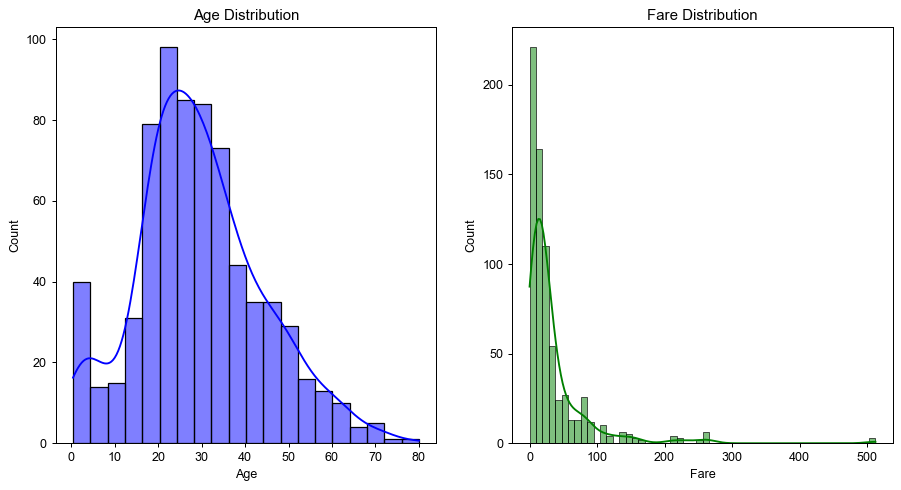

In [4]:
# 年龄和票价的分布
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(titanic_data['Age'], kde=True, color='blue')
plt.title('Age Distribution')

plt.subplot(1, 2, 2)
sns.histplot(titanic_data['Fare'], kde=True, color='green')
plt.title('Fare Distribution')

plt.show()

![原文参考图，当前结果见代码输出](attachments/img_002.png)

3.2 类别变量的可视化

查看性别和登船港口的分布。

/var/folders/q6/v6bs8gb12gd1lh35j2b7z3sc0000gn/T/ipykernel_11230/1794559983.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sex', data=titanic_data, palette='Set2')
/var/folders/q6/v6bs8gb12gd1lh35j2b7z3sc0000gn/T/ipykernel_11230/1794559983.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Embarked', data=titanic_data, palette='Set3')


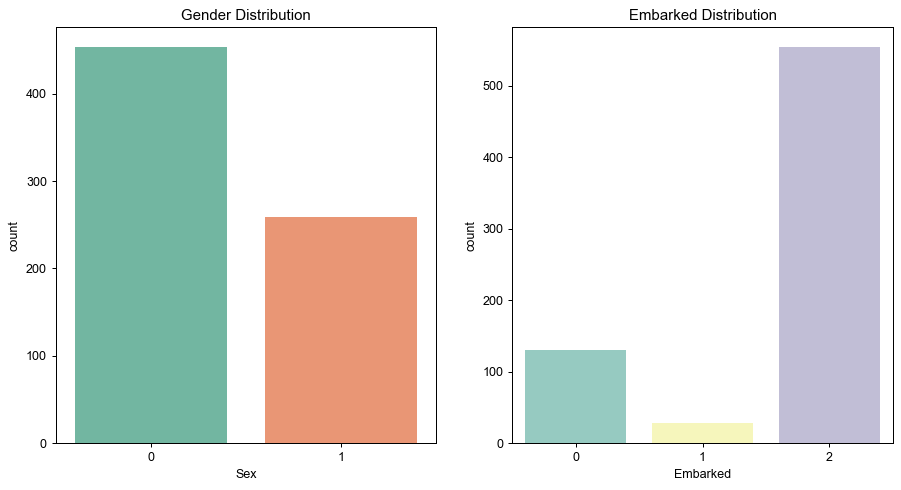

In [5]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.countplot(x='Sex', data=titanic_data, palette='Set2')
plt.title('Gender Distribution')

plt.subplot(1, 2, 2)
sns.countplot(x='Embarked', data=titanic_data, palette='Set3')
plt.title('Embarked Distribution')

plt.show()

![原文参考图，当前结果见代码输出](attachments/img_003.png)

**4. 随机森林模型的超参数优化**

我们使用贝叶斯优化来调整随机森林的超参数。

In [6]:
# 定义搜索空间
param_grid = {
    'n_estimators': Integer(50, 200),
    'max_depth': Integer(3, 20),
    'min_samples_split': Integer(2, 20),
    'min_samples_leaf': Integer(1, 20),
    'max_features': ['sqrt', 'log2'],
}

# 使用贝叶斯优化进行超参数搜索
bayes_search = BayesSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    search_spaces=param_grid,
    n_iter=12,
    cv=3,
    n_jobs=1,
    random_state=42,
    scoring='accuracy'
, error_score='raise')

# 拟合模型
bayes_search.fit(X_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,search_spaces,"{'max_depth': Integer(low=3...m='normalize'), 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': Integer(low=1...m='normalize'), 'min_samples_split': Integer(low=2...m='normalize'), ...}"
,optimizer_kwargs,None
,n_iter,12
,scoring,'accuracy'
,fit_params,None
,n_jobs,1
,n_points,1
,iid,'deprecated'
,refit,True
,cv,3


**5. 结果分析和可视化**

5.1 模型性能评估

在测试集上评估模型的性能。

Accuracy: 0.8111888111888111
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.87      0.85        85
           1       0.79      0.72      0.76        58

    accuracy                           0.81       143
   macro avg       0.81      0.80      0.80       143
weighted avg       0.81      0.81      0.81       143



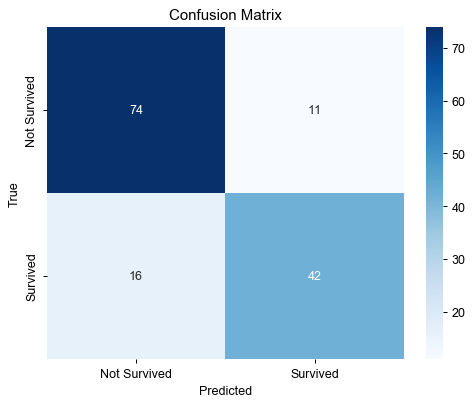

In [7]:
# 最优模型
best_model = bayes_search.best_estimator_

# 预测
y_pred = best_model.predict(X_test)

# 模型评估
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# 混淆矩阵
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Survived', 'Survived'], yticklabels=['Not Survived', 'Survived'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_004.png)

5.2 超参数与性能关系可视化

展示超参数如何影响模型性能。

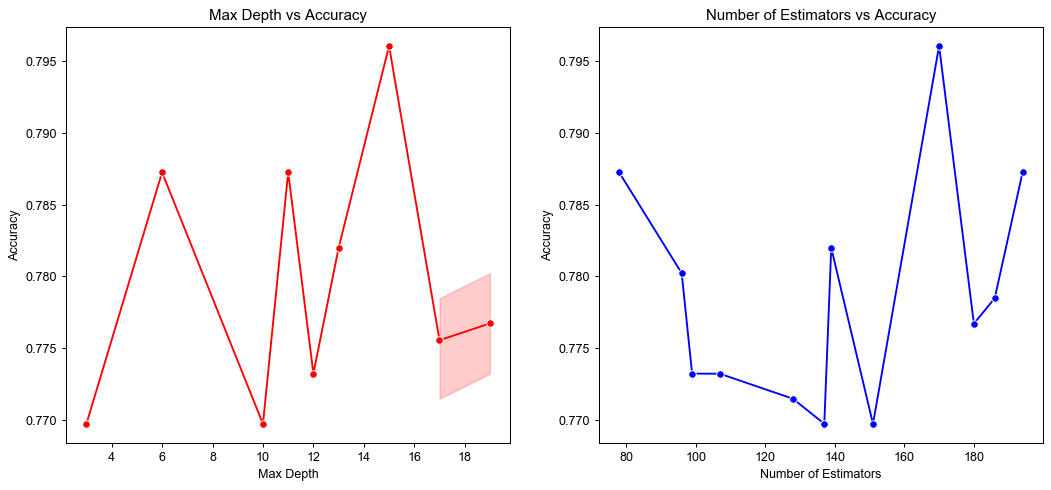

In [8]:
# 提取搜索过程中的所有参数组合和对应的得分
results = pd.DataFrame(bayes_search.cv_results_)

# 以 max_depth 和 n_estimators 为例，展示它们与准确率的关系
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.lineplot(x=results['param_max_depth'], y=results['mean_test_score'], marker='o', color='red')
plt.title('Max Depth vs Accuracy')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')

plt.subplot(1, 2, 2)
sns.lineplot(x=results['param_n_estimators'], y=results['mean_test_score'], marker='o', color='blue')
plt.title('Number of Estimators vs Accuracy')
plt.xlabel('Number of Estimators')
plt.ylabel('Accuracy')

plt.show()

通过贝叶斯优化，我们可以在相对较少的搜索次数下找到表现良好的超参数组合，从而提高模型在测试集上的表现。可视化图展示了不同超参数如何影响模型性能。